<a href="https://colab.research.google.com/github/ParusSlava/DTA_2026/blob/main/ML/Classification_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [25]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{cdf['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [26]:
from sklearn.model_selection import train_test_split

X = df[['tenure', 'monthly', 'support', 'age']] # features - ознаки
y = df['churn'] # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print('Навчальна вибірка:', X_train.shape[0], 'клієнтів')
print('Тестова вибірка:', X_test.shape[0], 'клієнтів')

Навчальна вибірка: 960 клієнтів
Тестова вибірка: 240 клієнтів


In [27]:
y_test

,churn
382,0
241,1
7,0
1071,0
1172,0
...,...
403,0
516,0
1069,1
63,0


In [28]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


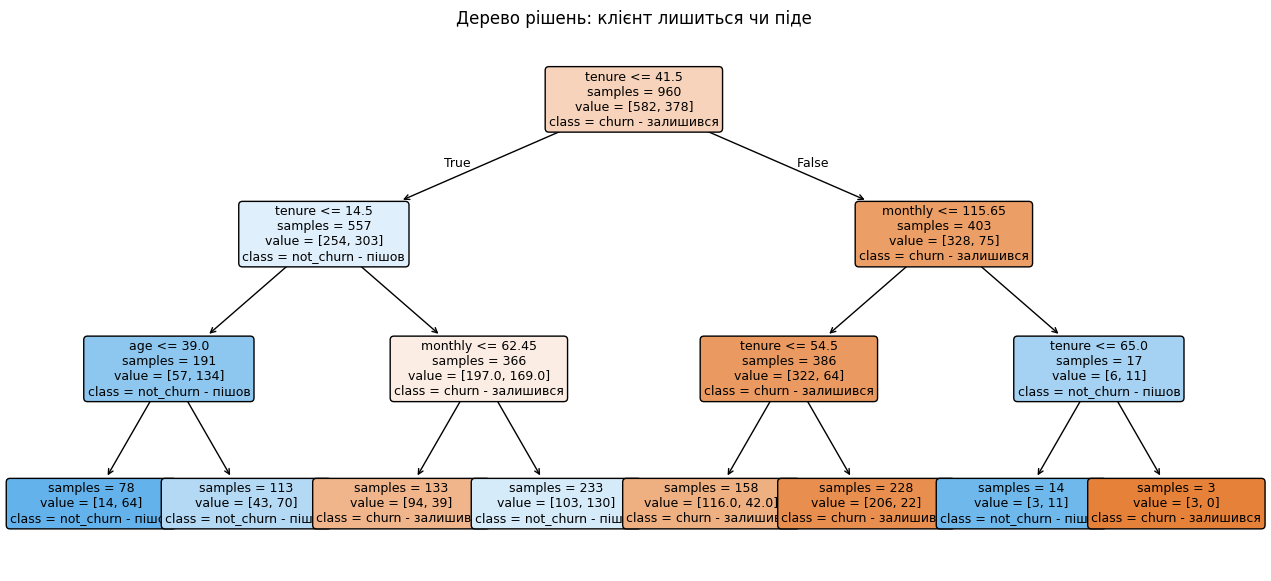

In [30]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['churn - залишився', 'not_churn - пішов'],
    filled=True, rounded=True, fontsize=9, impurity=False

    )

plt.title('Дерево рішень: клієнт лишиться чи піде')
plt.show()